In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)
import joblib

In [3]:
data_dir = "/content/drive/MyDrive/Intern_P2/spam.csv"

In [4]:
df = pd.read_csv(data_dir, encoding="cp1252")

In [5]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [8]:
print(df.shape)
print(df['label'].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


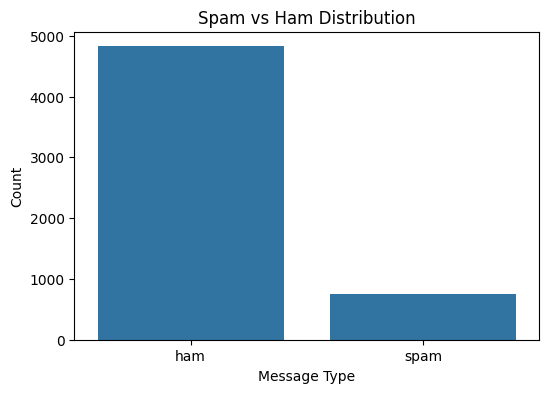

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

Text Cleaning

In [10]:
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation marks
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# Create a new column with cleaned messages & display
df['clean_message'] = df['message'].apply(clean_text)
print(df[['message', 'clean_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in a wkly comp to win fa cup final ...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


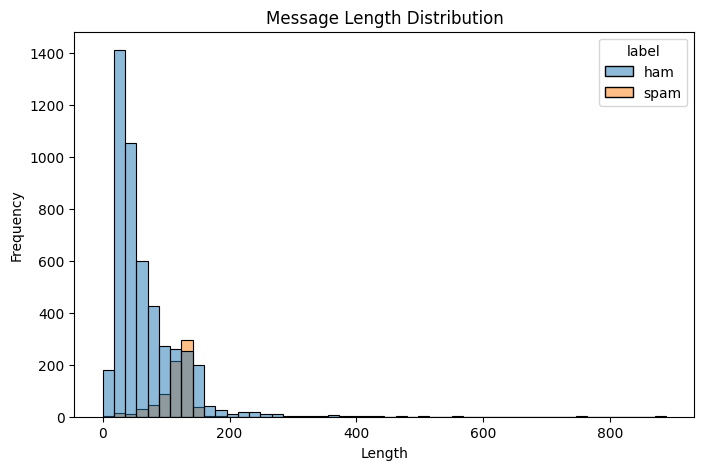

In [13]:
df['message_length'] = df['clean_message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

Encoding

In [ ]:
df['label_encoded'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# Input feature (text message)
X = df['clean_message']

# Target variable (spam or ham)
y = df['label_encoded']

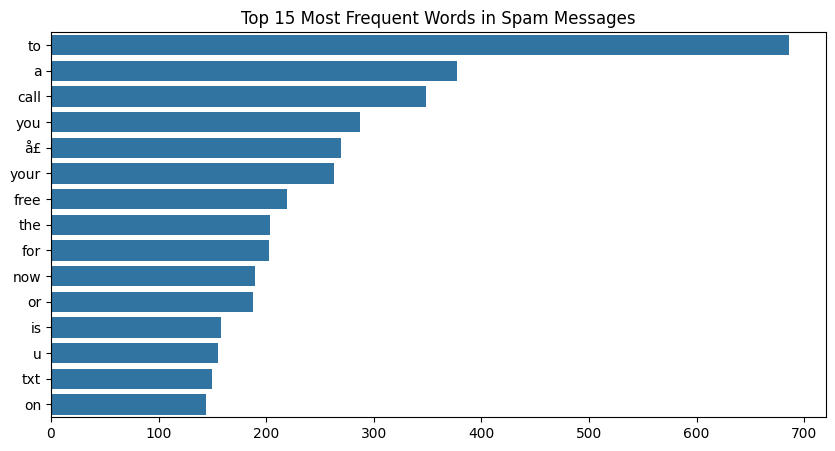

In [16]:
from collections import Counter

spam_words = " ".join(
    df[df['label']=='spam']['clean_message']
).split()

common_words = Counter(spam_words).most_common(15)

words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)

plt.title("Top 15 Most Frequent Words in Spam Messages")

plt.show()

Split dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42 )

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


Vectorization - TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tf = vectorizer.fit_transform(X_train)
X_test_tf = vectorizer.transform(X_test)

print("TF-IDF Shape:", X_train_tf.shape)

TF-IDF Shape: (4457, 5000)


Vectorization - CountVectorizer

In [ ]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)

X_train_cou = vectorizer.fit_transform(X_train)
X_test_cou = vectorizer.transform(X_test)

print("CountVectorizer shape:", X_train_cou.shape)

CountVectorizer shape: (4457, 5000)


Train Naive Bayes + CountVectorizer

In [ ]:
nb_bow = MultinomialNB() #Create model
nb_bow.fit(X_train_cou, y_train) #Train model
y_pred_nb_bow = nb_bow.predict(X_test_cou) #Predict on test data

print("Naive Bayes + CountVectorizer\n")
print(classification_report(y_test, y_pred_nb_bow, target_names=['Ham', 'Spam']))

Naive Bayes + CountVectorizer

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       965
        Spam       0.96      0.91      0.93       150

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



Train Naive Bayes + TF-IDF

In [ ]:
nb_tfidf = MultinomialNB() #Train model
nb_tfidf.fit(X_train_tf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tf)

print("Naive Bayes + TF-IDF\n")
print(classification_report(y_test, y_pred_nb_bow, target_names=['Ham', 'Spam']))

Naive Bayes + TF-IDF

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       965
        Spam       0.96      0.91      0.93       150

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



Train Logistic Regression + CountVectorizer

In [ ]:
lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_train_cou, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_cou)

print("Logistic Regression + CountVectorizer\n")
print(classification_report(y_test, y_pred_nb_bow, target_names=['Ham', 'Spam']))

Logistic Regression + CountVectorizer

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       965
        Spam       0.96      0.91      0.93       150

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



Train Naive Bayes + TF-IDF

In [ ]:
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tf)

print("Logistic Regression + TF-IDF\n")
print(classification_report(y_test, y_pred_lr_tfidf, target_names=['Ham', 'Spam']))

Logistic Regression + TF-IDF

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       965
        Spam       0.98      0.69      0.81       150

    accuracy                           0.96      1115
   macro avg       0.97      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



Compare all models

               Model  Accuracy  Precision   Recall  F1 Score
NB + CountVectorizer  0.982063   0.957746 0.906667  0.931507
LR + CountVectorizer  0.974888   0.991935 0.820000  0.897810
         NB + TF-IDF  0.971300   1.000000 0.786667  0.880597
         LR + TF-IDF  0.956054   0.980952 0.686667  0.807843


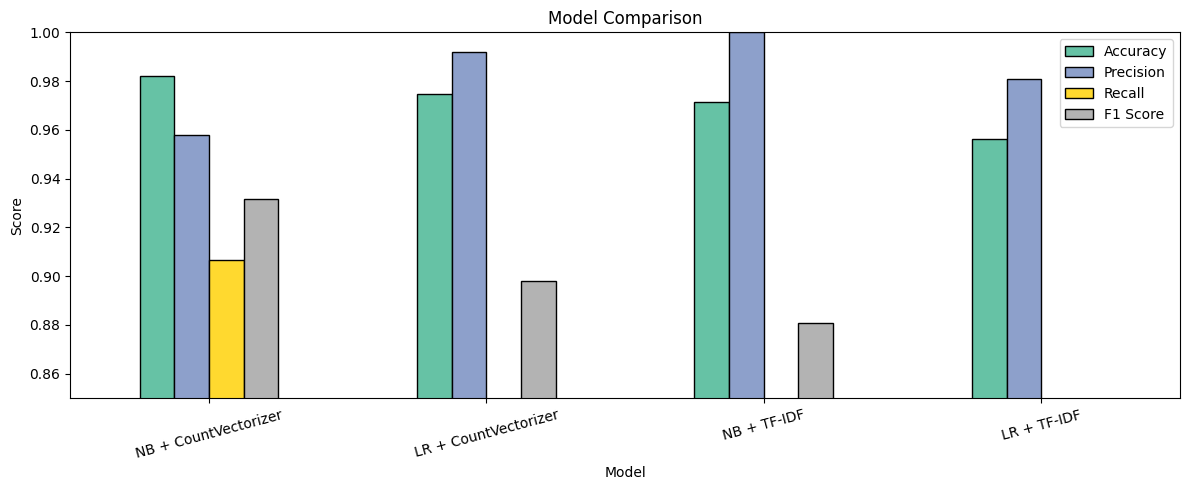

In [ ]:
models = {
    'NB + CountVectorizer' : y_pred_nb_bow,
    'LR + CountVectorizer' : y_pred_lr_bow,
    'NB + TF-IDF'          : y_pred_nb_tfidf,
    'LR + TF-IDF'          : y_pred_lr_tfidf
}

results = []
for name, preds in models.items():
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'F1 Score' : f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black'
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()


Find Best Model

In [ ]:
best_model_name = results_df.loc[
    results_df['F1 Score'].idxmax(), 'Model']
print('Best Model: ',best_model_name)

Best Model:  NB + CountVectorizer


Save Model

In [ ]:
count_vectorizer = CountVectorizer(stop_words='english', max_features=5000)
count_vectorizer.fit(X_train)

# Save trained model
joblib.dump(
    nb_bow, # Changed from nb_count to nb_bow
    'spam_classifier.pkl'
)

# Save CountVectorizer
joblib.dump(
    count_vectorizer,
    'count_vectorizer.pkl'
)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


Load Model

In [ ]:
# Load model
loaded_model = joblib.load(
    'spam_classifier.pkl'
)

# Load vectorizer
loaded_vectorizer = joblib.load(
    'count_vectorizer.pkl'
)

print("Loaded successfully!")

Loaded successfully!


Test with New Messages

In [ ]:
test_messages = [
    "Congratulations! You've won a free prize. Call now to claim!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Click here immediately.",
    "Can you send me the notes from today's class?",
    "Win a brand new iPhone today!",
    "Let's meet in the library at 2 PM.",
    "Claim your cash reward now!",
    "Happy Birthday! Have a great day.",
    "Limited-time offer! Free vouchers available.",
    "Don't forget to submit the assignment."
]

cleaned_messages = [clean_text(msg)
    for msg in test_messages
]

message_vectors = loaded_vectorizer.transform(cleaned_messages)

predictions = loaded_model.predict(message_vectors)

# Show predictions

for msg, pred in zip(test_messages, predictions):

    label = "Spam" if pred == 1 else "Ham"

    print(f"Message    : {msg}")
    print(f"Prediction : {label}")

Message    : Congratulations! You've won a free prize. Call now to claim!
Prediction : Spam
Message    : Hey, are we still meeting for lunch tomorrow?
Prediction : Ham
Message    : URGENT: Your account has been compromised. Click here immediately.
Prediction : Spam
Message    : Can you send me the notes from today's class?
Prediction : Ham
Message    : Win a brand new iPhone today!
Prediction : Spam
Message    : Let's meet in the library at 2 PM.
Prediction : Ham
Message    : Claim your cash reward now!
Prediction : Spam
Message    : Happy Birthday! Have a great day.
Prediction : Ham
Message    : Limited-time offer! Free vouchers available.
Prediction : Spam
Message    : Don't forget to submit the assignment.
Prediction : Ham


In [ ]:
test_messages = [
    "Congratulations! You've won a free prize. Call now to claim!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Click here immediately.",
    "Can you send me the notes from today's class?",
    "Win a brand new iPhone today!",
    "Let's meet in the library at 2 PM.",
    "Claim your cash reward now!",
    "Happy Birthday! Have a great day.",
    "Limited-time offer! Free vouchers available.",
    "Don't forget to submit the assignment."
]

cleaned_messages = [clean_text(msg)
    for msg in test_messages
]

message_vectors = loaded_vectorizer.transform(cleaned_messages)

predictions = loaded_model.predict(message_vectors)

# Show predictions

for msg, pred in zip(test_messages, predictions):

    label = "Spam" if pred == 1 else "Ham"
    print(f"[{label}] {msg}")

[Spam] Congratulations! You've won a free prize. Call now to claim!
[Ham] Hey, are we still meeting for lunch tomorrow?
[Spam] URGENT: Your account has been compromised. Click here immediately.
[Ham] Can you send me the notes from today's class?
[Spam] Win a brand new iPhone today!
[Ham] Let's meet in the library at 2 PM.
[Spam] Claim your cash reward now!
[Ham] Happy Birthday! Have a great day.
[Spam] Limited-time offer! Free vouchers available.
[Ham] Don't forget to submit the assignment.
